In [24]:
import matplotlib.pyplot as plt #Библиотека за визуелизација
import seaborn as sns
import numpy as np #Библиотека за нумерички анализи
import pandas as pd
from scipy import stats #Библиотека за статистички анализи
from sklearn.model_selection import train_test_split
from sklearn import datasets #Библиотека за податочни множества за машинско учење
from sklearn.preprocessing import MinMaxScaler #Min max Scaler за нормализација на податоци во опсег [0,1]
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, BayesianRidge #Вчитување на модели за линерна регресија
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score #За евалуација на модели

In [25]:
df = pd.read_csv("Student_Performance_dataset1.csv")
column_names = np.loadtxt(open("Student_Performance_dataset1.csv", "rb"), delimiter=",", max_rows=1, dtype = str)

In [26]:
df.head(5)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [27]:
df['Extracurricular Activities']=df['Extracurricular Activities'].map({'Yes': 1, 'No': 0})

In [28]:
df.head(5)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


In [29]:
X = df.iloc[:, 1:].to_numpy().astype(float)
y = df.iloc[:, 0].to_numpy().astype(float)

N = X.shape[0]
number_of_features = X.shape[1]

print(X.shape)
print(y.shape)
print("Карактеристики (Атрибути): ", column_names[:-1])
print("Број на карактеристики (атрибути):", X.shape[1]) # или number_of_features
print("Број на излезни класи: ", len(np.unique(y)))
print("Број на инстанци: ", X.shape[0]) # или N

(10000, 5)
(10000,)
Карактеристики (Атрибути):  ['Hours Studied' 'Previous Scores' 'Extracurricular Activities'
 'Sleep Hours' 'Sample Question Papers Practiced']
Број на карактеристики (атрибути): 5
Број на излезни класи:  9
Број на инстанци:  10000


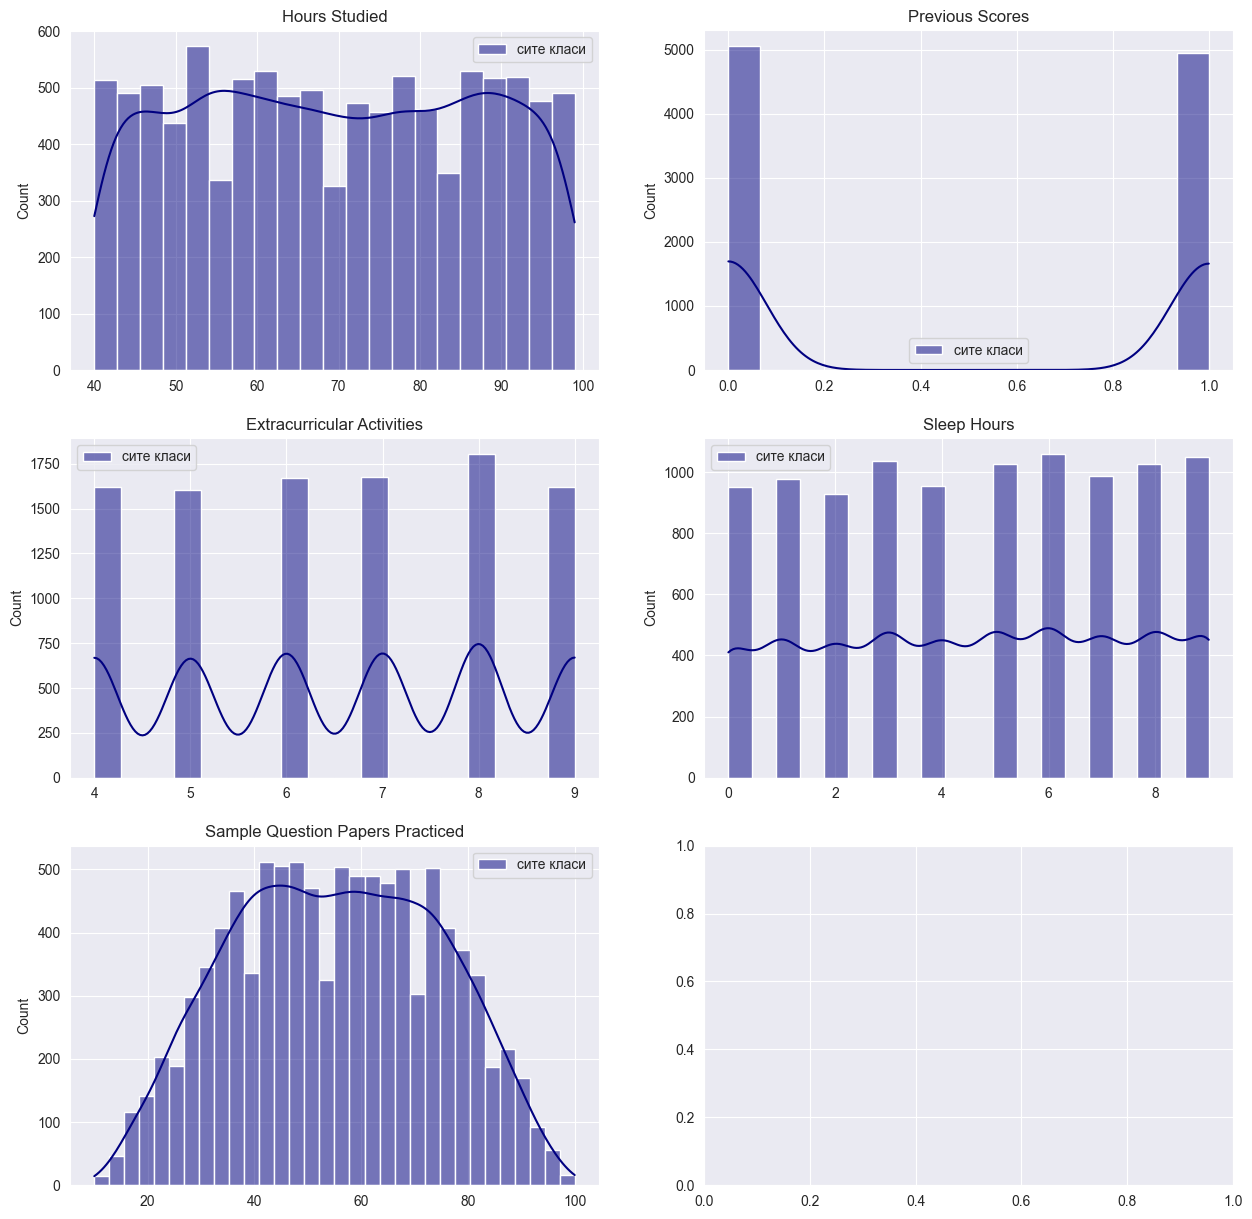

In [39]:
feature_names=column_names[:-1]
fig = plt.figure(figsize=(15, 15))
fig.subplots(nrows=3, ncols=2)
for feat_i in range(number_of_features): #хистограми за секој атрибут
    ax = plt.subplot(3,2, feat_i+1)
    plt.title(feature_names[feat_i])
    sns.histplot(X[:,feat_i],color='navy',label='сите класи',kde=True,stat="count")
    plt.legend()
plt.show()

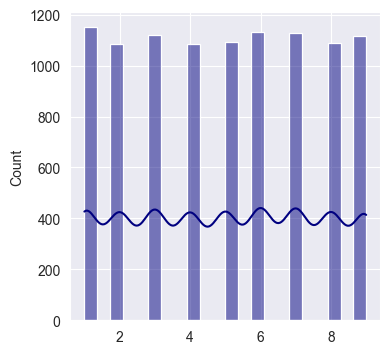

In [33]:
fig = plt.figure(figsize=(4, 4))
sns.histplot(y, color = "navy", kde=True)
plt.show()

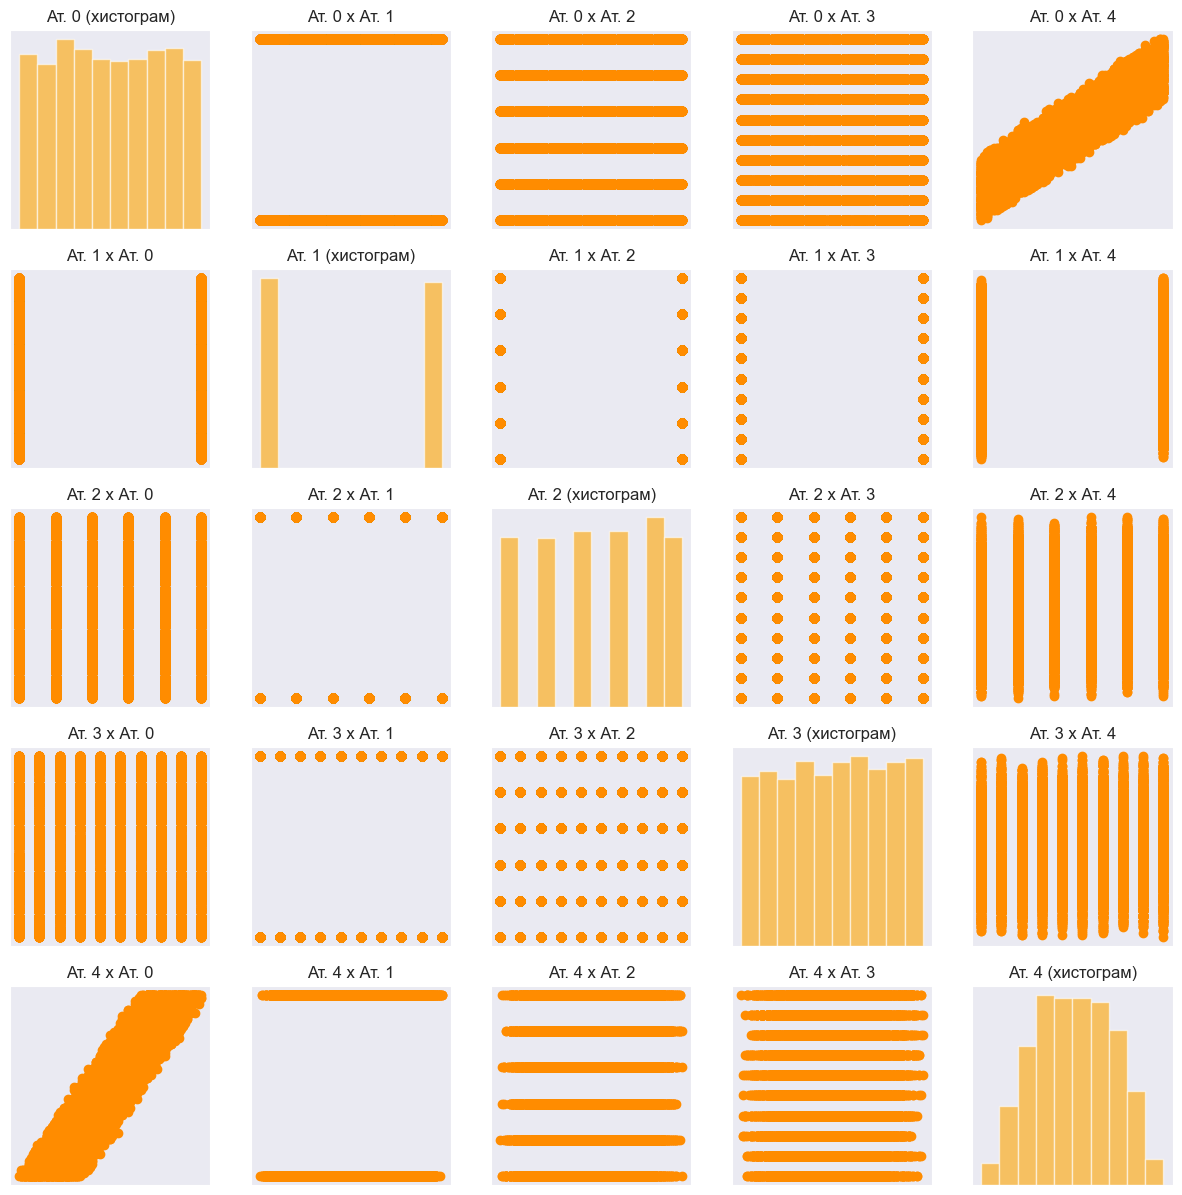

In [40]:
fig = plt.figure(figsize=(15, 15))
fig.subplots(nrows=number_of_features, ncols=number_of_features)
for feature_i in range(number_of_features):
    for feature_j in range(number_of_features):
        ax = plt.subplot(number_of_features,number_of_features,number_of_features*feature_i + feature_j+1)
        if feature_i==feature_j:
          plt.hist(X[:, feature_i], alpha=.6, color="orange")
          plt.title("Ат. "+str(feature_i)+" (хистограм)")
        else:
          plt.scatter(X[:,feature_i], X[:,feature_j], color="darkorange")
          plt.title("Ат. "+str(feature_i)+" x Ат. "+str(feature_j))
        plt.xticks(())
        plt.yticks(())
plt.show()

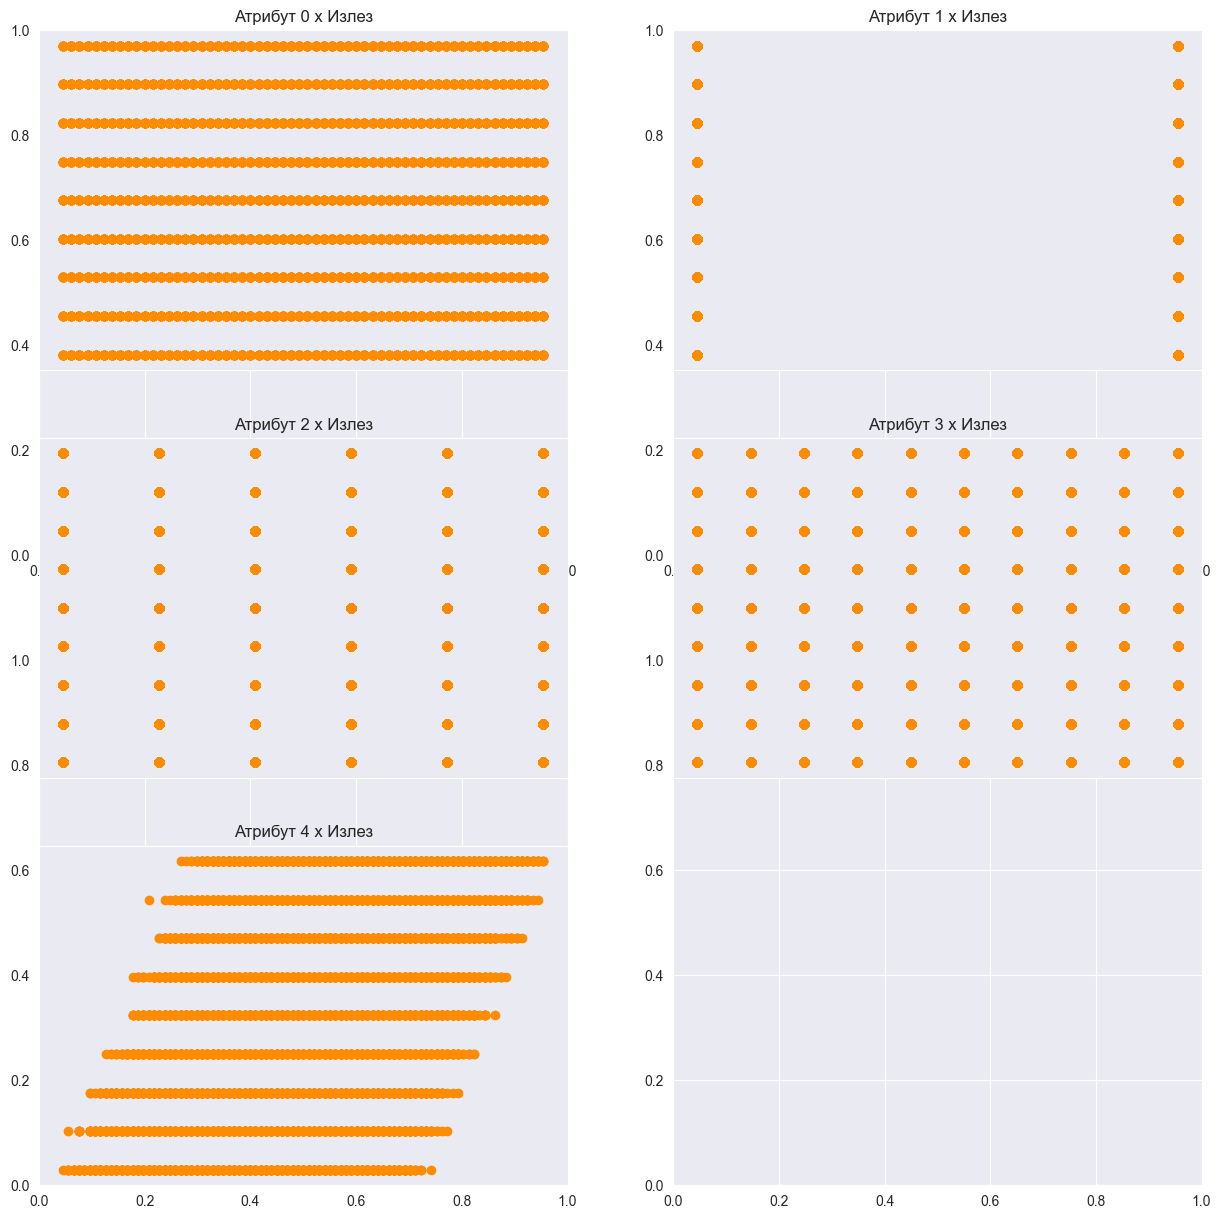

In [42]:
fig = plt.figure(figsize=(15, 15))
fig.subplots(nrows=(int)(number_of_features/2),ncols=2)
for feat_i in range(number_of_features):
    ax = plt.subplot(3,2, feat_i+1)
    plt.scatter( X[:,feat_i], y, color="darkorange")
    plt.xticks(())
    plt.yticks(())
    plt.title("Атрибут "+str(feat_i)+" x Излез")
plt.show()

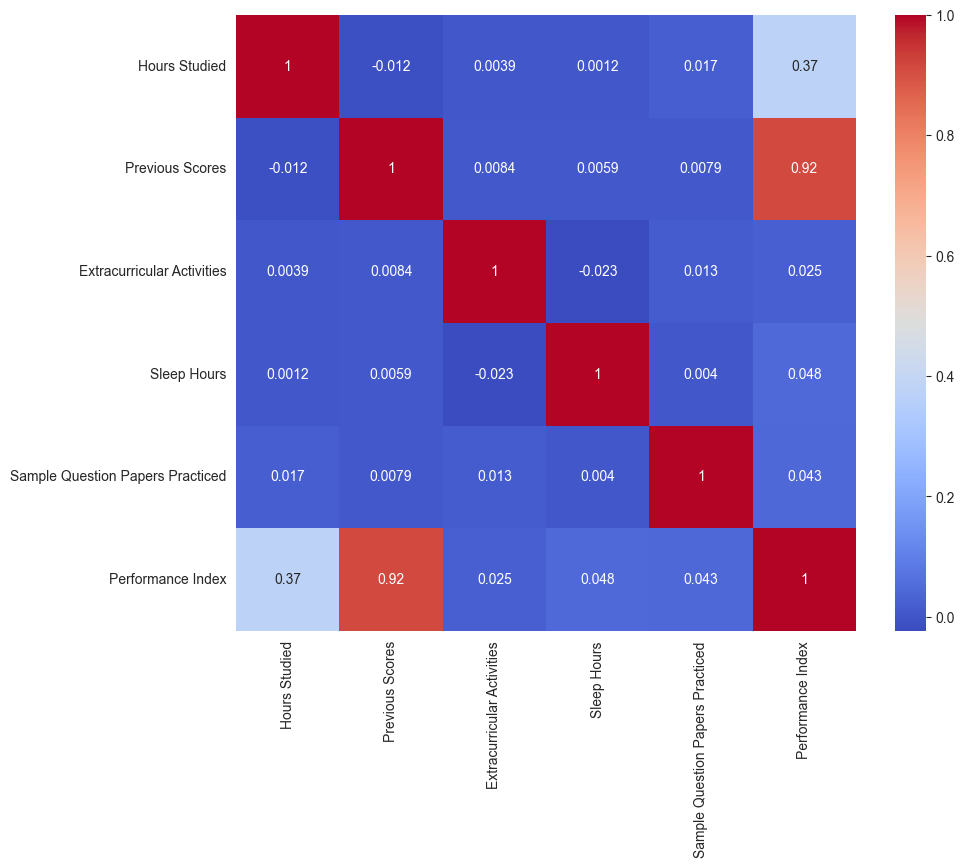

In [43]:
corr = df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [44]:
scaler = MinMaxScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

Коефициенти W:  [-19.48040404  -0.18825633  -0.7742545   -0.5507318   29.25295141]
Пресек W0:  0.7708660341805667
Средна квадратна грешка: 0.4689284424078086
Средна апсолутна грешка: 0.5478585438403294
Корен на средна квадратна грешка: 0.6847835003910423
R-квадрат:  0.929131143668084


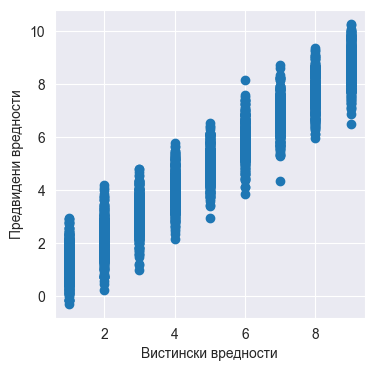

In [45]:
reg = LinearRegression().fit(X_train, y_train)
print("Коефициенти W: ", reg.coef_)
print("Пресек W0: ", reg.intercept_)

y_pred = reg.predict(X_test) # предвиди ги вредностите на тест податоците
print("Средна квадратна грешка:", mean_squared_error(y_test, y_pred))
print("Средна апсолутна грешка:", mean_absolute_error(y_test, y_pred))
print("Корен на средна квадратна грешка:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-квадрат: ", r2_score(y_test,y_pred)) # пресметај ја R - квадрат вредноста

# визуелизација на предвидените вредности од моделот
plt.figure(figsize=(4, 4))
plt.scatter(y_test,y_pred)
plt.xlabel("Вистински вредности")
plt.ylabel("Предвидени вредности")
plt.show()

Коефициенти W:  [-18.91797279  -0.1828148   -0.75017446  -0.53278017  28.45194897]
Пресек W0:  0.8686065126828924
Средна квадратна грешка: 0.47695263209282623
Средна апсолутна грешка: 0.5530073766834173
Корен на средна квадратна грешка: 0.6906175729684456
R-квадрат:  0.9279184530002976


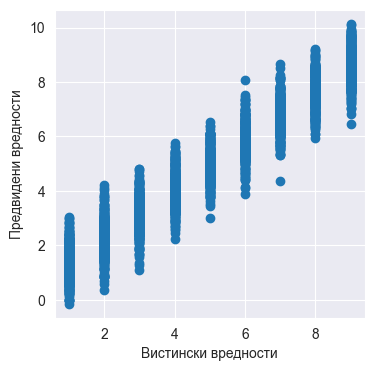

In [46]:
reg = Ridge(alpha=1).fit(X_train, y_train)
print("Коефициенти W: ", reg.coef_)
print("Пресек W0: ", reg.intercept_)

y_pred = reg.predict(X_test) # предвиди ги вредностите на тест податоците
print("Средна квадратна грешка:", mean_squared_error(y_test, y_pred))
print("Средна апсолутна грешка:", mean_absolute_error(y_test, y_pred))
print("Корен на средна квадратна грешка:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-квадрат: ", r2_score(y_test,y_pred)) # пресметај ја R - квадрат вредноста

# визуелизација на предвидените вредности од моделот
plt.figure(figsize=(4, 4))
plt.scatter(y_test,y_pred)
plt.xlabel("Вистински вредности")
plt.ylabel("Предвидени вредности")
plt.show()

Коефициенти W:  [-3.19833658 -0.         -0.         -0.          6.44307135]
Пресек W0:  3.3391489312889293
Средна квадратна грешка: 4.3644017705506615
Средна апсолутна грешка: 1.8006569824772096
Корен на средна квадратна грешка: 2.0891150687673146
R-квадрат:  0.34041074483827405


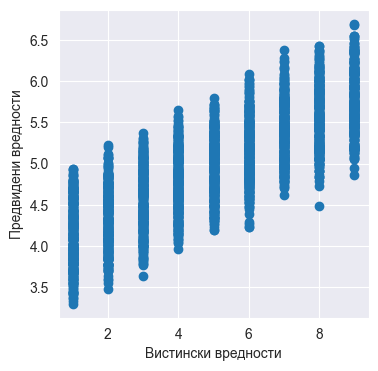

In [47]:
reg = Lasso(alpha = 0.1).fit(X_train, y_train)
print("Коефициенти W: ", reg.coef_)
print("Пресек W0: ", reg.intercept_)

y_pred = reg.predict(X_test) # предвиди ги вредностите на тест податоците
print("Средна квадратна грешка:", mean_squared_error(y_test, y_pred))
print("Средна апсолутна грешка:", mean_absolute_error(y_test, y_pred))
print("Корен на средна квадратна грешка:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-квадрат: ", r2_score(y_test,y_pred)) # пресметај ја R - квадрат вредноста

# визуелизација на предвидените вредности од моделот
plt.figure(figsize=(4, 4))
plt.scatter(y_test,y_pred)
plt.xlabel("Вистински вредности")
plt.ylabel("Предвидени вредности")
plt.show()

Коефициенти W:  [-0.51795726 -0.          0.          0.          1.81433398]
Пресек W0:  4.329225590066608
Средна квадратна грешка: 5.945969328641068
Средна апсолутна грешка: 2.106469536443407
Корен на средна квадратна грешка: 2.4384358364822862
R-квадрат:  0.1013894487999899


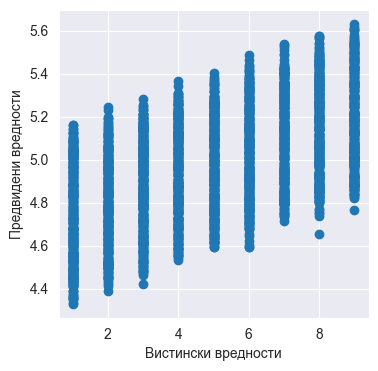

In [48]:
reg = ElasticNet(alpha = 0.1, l1_ratio = 0.3).fit(X_train, y_train)
print("Коефициенти W: ", reg.coef_)
print("Пресек W0: ", reg.intercept_)

y_pred = reg.predict(X_test) # предвиди ги вредностите на тест податоците
print("Средна квадратна грешка:", mean_squared_error(y_test, y_pred))
print("Средна апсолутна грешка:", mean_absolute_error(y_test, y_pred))
print("Корен на средна квадратна грешка:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-квадрат: ", r2_score(y_test,y_pred)) # пресметај ја R - квадрат вредноста

# визуелизација на предвидените вредности од моделот
plt.figure(figsize=(4, 4))
plt.scatter(y_test,y_pred)
plt.xlabel("Вистински вредности")
plt.ylabel("Предвидени вредности")
plt.show()

Коефициенти W:  [-19.47928749  -0.18824552  -0.7742067   -0.55069615  29.25136134]
Пресек W0:  0.7710600189757928
Средна квадратна грешка: 0.46893523272294313
Средна апсолутна грешка: 0.5478641352759693
[0.69122343 0.69131383 0.69149782 ... 0.6912258  0.69190051 0.69124047]
3000
Корен на средна квадратна грешка: 0.6847884583745137
R-квадрат:  0.9291301174520898


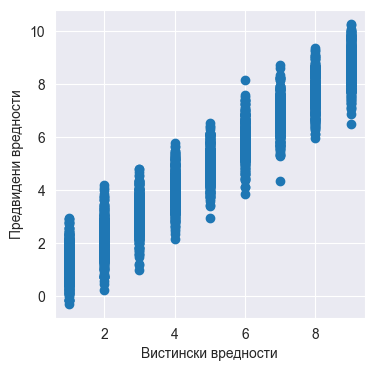

In [49]:
reg = BayesianRidge().fit(X_train, y_train)
print("Коефициенти W: ", reg.coef_)
print("Пресек W0: ", reg.intercept_)

y_pred, y_std = reg.predict(X_test, return_std = True) # предвиди ги вредностите на тест податоците
print("Средна квадратна грешка:", mean_squared_error(y_test, y_pred))
print("Средна апсолутна грешка:", mean_absolute_error(y_test, y_pred))
print(y_std)
print(len(y_std))
print("Корен на средна квадратна грешка:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-квадрат: ", r2_score(y_test, y_pred)) # пресметај ја R - квадрат вредноста

# визуелизација на предвидените вредности од моделот
plt.figure(figsize=(4, 4))
plt.scatter(y_test,y_pred)
plt.xlabel("Вистински вредности")
plt.ylabel("Предвидени вредности")
plt.show()

In [50]:
#kolku prvio feuture vlijaj na atributite

Xi=X[:,0].reshape(-1,1)
print("Xi=", Xi)
print("y=",y)

# поставете модел на линеарна регресија
lr = LinearRegression() # иницијализација на моделот
lr.fit(Xi, y) # поставете го моделот на податоците
lrsigma = np.sum((y - lr.predict(Xi))**2) /(N-2) # пресметка на варијансата на моделот

# поставете модел на риџ регресија
ridge = Ridge(alpha=1)
ridge.fit(Xi, y)
ridgesigma = np.sum((y - ridge.predict(Xi))**2) /(N-2)

# поставете модел на ласо регресија
lasso = Lasso(alpha=0.1)
lasso.fit(Xi, y)
lassosigma = np.sum((y - lasso.predict(Xi))**2) /(N-2)

# поставете модел на еластична мрежа
elastic = ElasticNet(alpha=0.1, l1_ratio = 0.4)
elastic.fit(Xi, y)
elasticsigma = np.sum((y - elastic.predict(Xi))**2) /(N-2)

# поставете модел на баесова риџ регресија
Bayes = BayesianRidge()
Bayes.fit(Xi, y)

print("Коефициенти на моделите")
print("Линеарна регресија: ",lr.coef_)
print("Риџ регресија: ", ridge.coef_)
print("Ласо регресија: ", lasso.coef_)
print("Регресија на еластична мрежа:", elastic.coef_)
print("Баесова риџ регресија: ", Bayes.coef_)

Xi= [[1.        ]
 [0.71186441]
 [0.18644068]
 ...
 [0.72881356]
 [0.96610169]
 [0.57627119]]
y= [7. 4. 8. ... 6. 9. 7.]
Коефициенти на моделите
Линеарна регресија:  [-0.10913804]
Риџ регресија:  [-0.10901187]
Ласо регресија:  [-0.]
Регресија на еластична мрежа: [-0.]
Баесова риџ регресија:  [-0.03894036]


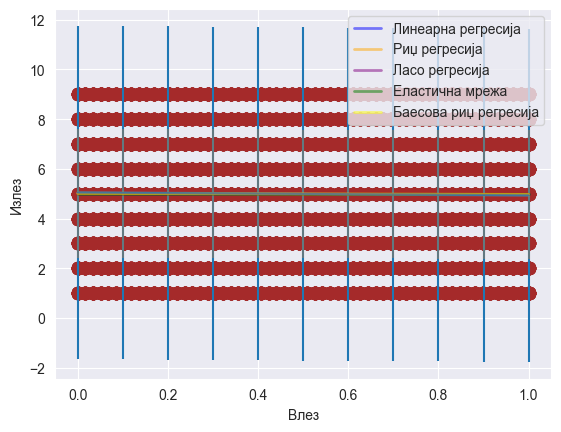

In [56]:
#Gi crta site regresioni modeli

# пресметка на линијата на секој модел во опсег [0, X.max()]
line_X = np.arange(0, 1.1, 0.1)[:, np.newaxis]
line_y = lr.predict(line_X)
line_y_ridge = ridge.predict(line_X)
line_y_lasso = lasso.predict(line_X)
line_y_elastic = elastic.predict(line_X)
line_y_bayes, Bayessigma = Bayes.predict(line_X, return_std = True) # во баесовиот модел може да се пресмета варијансата за секоја предикција

lw = 2 # параметар за визуелизација (linewidth)
plt.figure() # ги цртаме податочните точки и ги цртаме линиите што ги претставуваат различните модели, ги цртаме и лентите за грешки на моделите за линеарна и баесова риџ регресија
plt.scatter(Xi, y, color='brown', marker='.', s = 300)
plt.plot(line_X, line_y, color='blue', linewidth=lw, label='Линеарна регресија', alpha=0.5)
plt.errorbar(line_X, line_y,yerr=lrsigma)
plt.plot(line_X, line_y_ridge, color='orange', linewidth=lw, label='Риџ регресија', alpha=0.5)
plt.plot(line_X, line_y_lasso, color='purple', linewidth=lw, label='Ласо регресија', alpha=0.5)
plt.plot(line_X, line_y_elastic, color="green", linewidth=lw, label='Eластичнa мрежa', alpha=0.5)
plt.plot(line_X, line_y_bayes, color="yellow", linewidth=lw, label='Баесова риџ регресија', alpha=0.5)
plt.errorbar(line_X, line_y_bayes, yerr=Bayessigma, alpha = 0.3)

plt.legend(loc='best')
plt.xlabel("Влез")
plt.ylabel("Излез")
plt.show()

In [58]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)

X_train_poly2 = poly.fit_transform(X_train)
X_test_poly2 = poly.transform(X_test)

model_linear = LinearRegression()
model_linear.fit(X_train_poly2, y_train)

# 4. Prediction
y_pred = model_linear.predict(X_test_poly2)

# 5. Evaluation
print("Linear Regresion")
print("MSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

Linear Regresion
MSE: 0.46973371951968224
R²: 0.929009442651921
